Calculando curva de energia potencial do H2...

  Dist (Å) |      HF (Ha) |     FCI (Ha) |     VQE (Ha) |     PBE (Ha) | Erro VQE (mHa)
--------------------------------------------------------------------------------
     0.300 |    -0.593828 |    -0.601804 |    -0.601779 |    -0.619544 |         0.0244
     0.500 |    -1.042996 |    -1.055160 |    -1.055159 |    -1.070663 |         0.0003
     0.700 |    -1.117349 |    -1.136189 |    -1.136189 |    -1.151011 |         0.0000
     0.740 |    -1.116759 |    -1.137284 |    -1.137284 |    -1.152073 |         0.0000
     0.900 |    -1.091914 |    -1.120560 |    -1.120535 |    -1.135205 |         0.0257
     1.100 |    -1.036539 |    -1.079193 |    -1.079193 |    -1.092624 |         0.0001
     1.300 |    -0.973111 |    -1.035186 |    -1.035186 |    -1.044442 |         0.0001
     1.500 |    -0.910874 |    -0.998149 |    -0.998149 |    -0.998737 |         0.0002
     1.750 |    -0.841349 |    -0.966335 |    -0.966331 |    -0.949875 |       

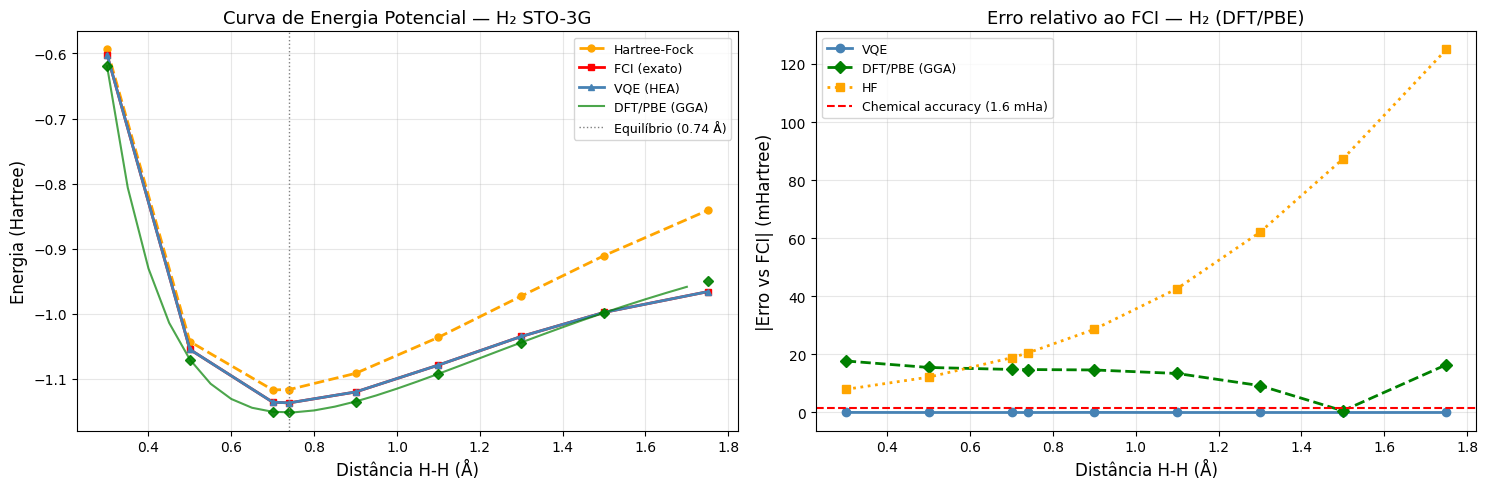


Distância de equilíbrio VQE: 0.740 Å
Distância de equilíbrio FCI: 0.740 Å
Distância de equilíbrio PBE: 0.750 Å

Erro máximo VQE vs FCI: 0.0257 mHartree
Erro médio  VQE vs FCI: 0.0060 mHartree
Erro máximo PBE vs FCI: 17.7401 mHartree
Erro médio  PBE vs FCI: 13.0259 mHartree

Chemical accuracy VQE: ATINGIDA ✓
Chemical accuracy PBE: NÃO atingida ✗


In [1]:
import pennylane as qml
from pennylane import numpy as np
import numpy as np_orig
import matplotlib.pyplot as plt
from pyscf import gto, scf, fci
from scipy.interpolate import interp1d

# ── Dados DFT/PBE fornecidos externamente ────────────────────
dft_data = np_orig.array([
    [0.30, -0.619543783539],
    [0.35, -0.806300027379],
    [0.40, -0.930559926211],
    [0.45, -1.014314866697],
    [0.50, -1.070662546259],
    [0.55, -1.107843030361],
    [0.60, -1.131301523247],
    [0.65, -1.144796417606],
    [0.70, -1.151010514590],
    [0.75, -1.151899939672],
    [0.80, -1.148904044829],
    [0.85, -1.143080160270],
    [0.90, -1.135205305373],
    [0.95, -1.125848654537],
    [1.00, -1.115433111978],
    [1.05, -1.104275820995],
    [1.10, -1.092623718137],
    [1.15, -1.080670306391],
    [1.20, -1.068574132788],
    [1.25, -1.056463005466],
    [1.30, -1.044442324996],
    [1.35, -1.032598321278],
    [1.40, -1.020998607465],
    [1.45, -1.009697527816],
    [1.50, -0.998737441282],
    [1.55, -0.988148814642],
    [1.60, -0.977955378089],
    [1.65, -0.968172791043],
    [1.70, -0.958810027041],
])
dft_dist   = dft_data[:, 0]
dft_energy = dft_data[:, 1]


def calcula_h2(distancia, n_camadas=2, n_iter=200):
    """
    Roda HF, FCI e VQE para o H2 numa dada distância internuclear.
    Retorna (energia_hf, energia_fci, energia_vqe)
    """
    mol = gto.Mole()
    mol.atom    = f'H 0 0 0; H 0 0 {distancia}'
    mol.basis   = 'sto-3g'
    mol.unit    = 'Angstrom'
    mol.verbose = 0
    mol.build()

    mf = scf.RHF(mol)
    e_hf = mf.kernel()

    cisolver = fci.FCI(mf)
    e_fci, _ = cisolver.kernel()

    geometry = np_orig.array([[0.0, 0.0, 0.0],
                               [0.0, 0.0, distancia / 0.529177]])

    hamiltoniano, qubits = qml.qchem.molecular_hamiltonian(
        ['H', 'H'],
        geometry,
        basis='sto-3g',
        mapping='jordan_wigner'
    )

    dev      = qml.device('default.qubit', wires=qubits)
    n_params = qubits * 2 * n_camadas

    def camada_hea(params, camada):
        offset = camada * qubits * 2
        for i in range(qubits):
            qml.RY(params[offset + i],          wires=i)
            qml.RZ(params[offset + qubits + i], wires=i)
        for i in range(qubits - 1):
            qml.CNOT(wires=[i, i + 1])

    @qml.qnode(dev)
    def circuito_hea(params):
        for i in range(qubits):
            qml.Hadamard(wires=i)
        for c in range(n_camadas):
            camada_hea(params, c)
        return qml.expval(hamiltoniano)

    np_orig.random.seed(42)
    params = np.array(
        np_orig.random.uniform(-np_orig.pi, np_orig.pi, n_params),
        requires_grad=True
    )
    opt = qml.AdamOptimizer(stepsize=0.05)

    for i in range(n_iter):
        params, energia = opt.step_and_cost(circuito_hea, params)

    return e_hf, e_fci, float(energia)


# ── Curva de energia potencial ───────────────────────────────
distancias = np_orig.array([
    0.3, 0.5, 0.7, 0.74, 0.9,
    1.1, 1.3, 1.5, 1.75
])

energias_hf  = []
energias_fci = []
energias_vqe = []

print('Calculando curva de energia potencial do H2...\n')
print(f'{"Dist (Å)":>10} | {"HF (Ha)":>12} | {"FCI (Ha)":>12} | {"VQE (Ha)":>12} | {"PBE (Ha)":>12} | {"Erro VQE (mHa)":>14}')
print('-' * 80)

dft_interp = interp1d(dft_dist, dft_energy, kind='cubic',
                      bounds_error=False, fill_value='extrapolate')

for d in distancias:
    e_hf, e_fci, e_vqe = calcula_h2(d)
    energias_hf.append(e_hf)
    energias_fci.append(e_fci)
    energias_vqe.append(e_vqe)
    e_dft = float(dft_interp(d))
    erro  = abs(e_vqe - e_fci) * 1000
    print(f'{d:>10.3f} | {e_hf:>12.6f} | {e_fci:>12.6f} | {e_vqe:>12.6f} | {e_dft:>12.6f} | {erro:>14.4f}')


# ── Gráfico ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — Gráfico 1: curva de energia potencial —
ax = axes[0]
ax.plot(distancias, energias_hf,  'o--', color='orange',
        linewidth=2, markersize=5, label='Hartree-Fock')
ax.plot(distancias, energias_fci, 's-',  color='red',
        linewidth=2, markersize=5, label='FCI (exato)')
ax.plot(distancias, energias_vqe, '^-',  color='steelblue',
        linewidth=2, markersize=5, label='VQE (HEA)')
ax.plot(dft_dist, dft_energy, '-',  color='green',
        linewidth=1.5, alpha=0.7, label='DFT/PBE (GGA)')
ax.plot(distancias, dft_interp(distancias), 'D',
        color='green', markersize=5, alpha=0.9)

ax.axvline(x=0.74, color='gray', linestyle=':',
           linewidth=1, label='Equilíbrio (0.74 Å)')
ax.set_xlabel('Distância H-H (Å)', fontsize=12)
ax.set_ylabel('Energia (Hartree)', fontsize=12)
ax.set_title('Curva de Energia Potencial — H₂ STO-3G', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# — Gráfico 2: erros vs FCI —
ax2 = axes[1]
erros_vqe = [abs(v - f) * 1000 for v, f in zip(energias_vqe, energias_fci)]
erros_dft = [abs(float(dft_interp(d)) - f) * 1000
             for d, f in zip(distancias, energias_fci)]
erros_hf  = [abs(h - f) * 1000 for h, f in zip(energias_hf,  energias_fci)]

ax2.plot(distancias, erros_vqe, 'o-',  color='steelblue',
         linewidth=2, markersize=6, label='VQE')
ax2.plot(distancias, erros_dft, 'D--', color='green',
         linewidth=2, markersize=6, label='DFT/PBE (GGA)')
ax2.plot(distancias, erros_hf,  's:',  color='orange',
         linewidth=2, markersize=6, label='HF')
ax2.axhline(y=1.6, color='red', linestyle='--',
            linewidth=1.5, label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Distância H-H (Å)', fontsize=12)
ax2.set_ylabel('|Erro vs FCI| (mHartree)', fontsize=12)
ax2.set_title('Erro relativo ao FCI — H₂ (DFT/PBE)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('h2_curva_energia_pbe.png', dpi=150)
plt.show()


# ── Resumo ────────────────────────────────────────────────────
idx_eq_vqe = np_orig.argmin(energias_vqe)
idx_eq_fci = np_orig.argmin(energias_fci)
idx_eq_dft = np_orig.argmin(dft_energy)

print(f'\nDistância de equilíbrio VQE: {distancias[idx_eq_vqe]:.3f} Å')
print(f'Distância de equilíbrio FCI: {distancias[idx_eq_fci]:.3f} Å')
print(f'Distância de equilíbrio PBE: {dft_dist[idx_eq_dft]:.3f} Å')

erros_vqe_arr = np_orig.array(erros_vqe)
erros_dft_arr = np_orig.array(erros_dft)

print(f'\nErro máximo VQE vs FCI: {erros_vqe_arr.max():.4f} mHartree')
print(f'Erro médio  VQE vs FCI: {erros_vqe_arr.mean():.4f} mHartree')
print(f'Erro máximo PBE vs FCI: {erros_dft_arr.max():.4f} mHartree')
print(f'Erro médio  PBE vs FCI: {erros_dft_arr.mean():.4f} mHartree')

print(f'\nChemical accuracy VQE: {"ATINGIDA ✓" if erros_vqe_arr.max() < 1.6 else "NÃO atingida ✗"}')
print(f'Chemical accuracy PBE: {"ATINGIDA ✓" if erros_dft_arr.max() < 1.6 else "NÃO atingida ✗"}')